# scRNA-seq preprocessing with kb-python (kallisto | bustools)

Every scRNA-seq study begins by turning raw 10x Genomics sequencing reads into
a gene-by-cell count matrix. This tutorial walks through that **preprocessing**
stage end-to-end using the **kb-python** backend on the
[pbmc_1k v3 dataset](https://support.10xgenomics.com/single-cell-gene-expression/datasets/3.0.0/pbmc_1k_v3)
from 10x Genomics, and then runs a basic downstream analysis with OmicVerse.

## The kallisto | bustools | kb-python pipeline

**kb-python** is the unified command-line front end for the
[kallisto | bustools](https://www.kallistobus.tools/) single-cell ecosystem. It
orchestrates two tools:

* **kallisto** performs ultra-fast *pseudoalignment* of the reads against a
  transcriptome index, emitting a BUS (Barcode-UMI-Set) file, and
* **bustools** sorts, corrects and collapses that BUS file into a
  UMI-deduplicated gene-by-cell count matrix.

Why pseudoalignment? Rather than computing full base-level alignments, kallisto
only determines the set of transcripts each read is *compatible* with. This is
extremely fast, has a small constant memory footprint, and is accurate for
gene-level quantification. kb-python wraps the whole chain (index build,
pseudoalignment, barcode correction, BUS sorting, counting) behind two commands.

OmicVerse exposes this as `ov.alignment.single`:

* `ov.alignment.single.ref(...)` -> `kb ref` (build a kallisto index + t2g map)
* `ov.alignment.single.count(...)` -> `kb count` (pseudoalign + quantify -> AnnData `.h5ad`)

The simpleaf / salmon / alevin-fry workflow is available as a second backend
through `ov.alignment.simpleaf` (see the
[simpleaf tutorial](t_alignment_1k) and the
[backend comparison](t_alignment_compare)).

If you find this tutorial helpful, please cite kb-python and OmicVerse:

* Sullivan, D.K., Min, K.H.(.), Hjorleifsson, K.E. et al. kallisto, bustools and
  kb-python for quantifying bulk, single-cell and single-nucleus RNA-seq.
  *Nature Protocols* (2025). https://doi.org/10.1038/s41596-024-01057-0
* Melsted, P., Booeshaghi, A.S., Liu, L. et al. Modular, efficient and constant-memory
  single-cell RNA-seq preprocessing. *Nature Biotechnology* 39, 813-818 (2021).
  https://doi.org/10.1038/s41587-021-00870-2

In [1]:
import omicverse as ov
import scanpy as sc
import pandas as pd
import numpy as np
import time
ov.plot_set()

/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


🔬 Starting plot initialization...
🧬 Detecting GPU devices…
🚫 No GPU devices found (CUDA/MPS/ROCm/XPU)

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.2.1rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



## Working directory and tool installation

kb-python is a pure-Python package that bundles the `kallisto` and `bustools`
binaries, so a single `pip` install is all you need:

```bash
pip install kb-python
```

Unlike the simpleaf backend (which needs a dedicated conda environment), the
OmicVerse wrappers find the `kb` executable automatically once it is installed
in the active Python environment. We keep all reference / FASTQ / output files
under a scratch directory with plenty of free disk (the genome FASTA, the index
and the FASTQs together need ~15 GB).

In [2]:
import os

# Scratch working directory (NOT the OmicVerse repo).
work_dir = "/scratch/users/steorra/kb_tutorial"
os.makedirs(work_dir, exist_ok=True)
os.chdir(work_dir)
print("Working directory:", os.getcwd())

Working directory: /scratch/users/steorra/kb_tutorial


## Download the reference genome and the sequencing reads

We need three inputs:

1. a **genome FASTA** and **GTF annotation** to build the kallisto transcriptome
   index (Ensembl GRCh38, release 108), and
2. the **pbmc_1k v3 FASTQ** reads from 10x Genomics.

If you have already downloaded these files for the simpleaf tutorial they can be
reused directly. Otherwise, fetch them with `wget` (the genome FASTA is ~840 MB
and the FASTQ archive is ~5 GB):

```bash
# Human genome FASTA + GTF annotation (Ensembl GRCh38, release 108)
wget -c https://ftp.ensembl.org/pub/release-108/fasta/homo_sapiens/dna/Homo_sapiens.GRCh38.dna.primary_assembly.fa.gz
wget -c https://ftp.ensembl.org/pub/release-108/gtf/homo_sapiens/Homo_sapiens.GRCh38.108.gtf.gz

# pbmc_1k v3 FASTQ reads (~5 GB tar archive from 10x Genomics)
wget -c https://cf.10xgenomics.com/samples/cell-exp/3.0.0/pbmc_1k_v3/pbmc_1k_v3_fastqs.tar
tar -xf pbmc_1k_v3_fastqs.tar
```

Here we point at the copy already downloaded under the simpleaf tutorial
directory and confirm every input file is present.

In [3]:
# Reuse the genome / GTF / FASTQ files already downloaded for the simpleaf run.
src = "/scratch/users/steorra/simpleaf_tutorial/pbmc_1k_v3"
fasta = f"{src}/Homo_sapiens.GRCh38.dna.primary_assembly.fa.gz"
gtf = f"{src}/Homo_sapiens.GRCh38.108.gtf.gz"
fastq_dir = f"{src}/pbmc_1k_v3_fastqs"
for f in (fasta, gtf, fastq_dir):
    print("OK " if os.path.exists(f) else "MISSING ", f)

OK  /scratch/users/steorra/simpleaf_tutorial/pbmc_1k_v3/Homo_sapiens.GRCh38.dna.primary_assembly.fa.gz
OK  /scratch/users/steorra/simpleaf_tutorial/pbmc_1k_v3/Homo_sapiens.GRCh38.108.gtf.gz
OK  /scratch/users/steorra/simpleaf_tutorial/pbmc_1k_v3/pbmc_1k_v3_fastqs


## Build the kallisto index

`ov.alignment.single.ref` runs `kb ref`, which (a) extracts the **cDNA**
(spliced transcript) sequences from the genome FASTA + GTF and (b) builds a
kallisto k-mer index from them, together with a transcript-to-gene (`t2g`) map
used to aggregate transcript counts to genes.

Key arguments:

* `fasta_paths` / `gtf_paths` - the genome FASTA and matching GTF annotation.
* `index_path` / `t2g_path` - where the kallisto index and t2g map are written.
* `cdna_path` - where the extracted cDNA FASTA is written.
* `threads` - worker threads for the index build.

This step reads the whole genome and is the most resource-intensive part of the
tutorial. We wrap it in `time.time()` so the wall-clock cost is recorded (it is
reused in the [backend comparison](t_alignment_compare)).

In [4]:
index_path = f"{work_dir}/index.idx"
t2g_path = f"{work_dir}/t2g.txt"

t0 = time.time()
ref_res = ov.alignment.single.ref(
    index_path=index_path,            # output kallisto index
    t2g_path=t2g_path,                # output transcript-to-gene map
    fasta_paths=fasta,                # genome FASTA
    gtf_paths=gtf,                    # GTF annotation
    cdna_path=f"{work_dir}/cdna.fa",  # extracted cDNA FASTA
    threads=12,
    overwrite=True,
)
ref_seconds = time.time() - t0
print(f"kb ref wall-clock time: {ref_seconds/60:.1f} min")

[kb ref] Starting ref workflow: standard


[kb ref] Using temporary directory: tmp-kb-629f2d5c66364c3ab5188fc04c71b37c


>> /scratch/users/steorra/env/omicdev/bin/kb ref --tmp tmp-kb-629f2d5c66364c3ab5188fc04c71b37c -i /scratch/users/steorra/kb_tutorial/index.idx -g /scratch/users/steorra/kb_tutorial/t2g.txt -t 12 --overwrite --d-list-overhang 1 -f1 /scratch/users/steorra/kb_tutorial/cdna.fa /scratch/users/steorra/simpleaf_tutorial/pbmc_1k_v3/Homo_sapiens.GRCh38.dna.primary_assembly.fa.gz /scratch/users/steorra/simpleaf_tutorial/pbmc_1k_v3/Homo_sapiens.GRCh38.108.gtf.gz


/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


[2026-05-21 15:31:51,962]    INFO [ref] Preparing /scratch/users/steorra/simpleaf_tutorial/pbmc_1k_v3/Homo_sapiens.GRCh38.dna.primary_assembly.fa.gz, /scratch/users/steorra/simpleaf_tutorial/pbmc_1k_v3/Homo_sapiens.GRCh38.108.gtf.gz


...

[2026-05-21 15:34:13,930]    INFO [ref] Concatenating 1 cDNAs to /scratch/users/steorra/kb_tutorial/cdna.fa


[2026-05-21 15:34:14,749]    INFO [ref] Creating transcript-to-gene mapping at /scratch/users/steorra/kb_tutorial/t2g.txt


[2026-05-21 15:34:16,852]    INFO [ref] Indexing /scratch/users/steorra/kb_tutorial/cdna.fa to /scratch/users/steorra/kb_tutorial/index.idx


[kb ref] ref workflow completed!


kb ref wall-clock time: 10.9 min


## Pseudoalign and quantify the reads

`ov.alignment.single.count` runs `kb count`, which performs the full chain:
kallisto pseudoaligns the FASTQs against the index (producing a BUS file),
then bustools sorts the records, corrects the cell barcodes against the 10x
whitelist, and collapses UMIs into a gene-by-cell count matrix.

Key arguments:

* `technology="10XV3"` - the reads were generated with 10x Chromium Single Cell
  3' v3 chemistry (16 bp barcode + 12 bp UMI); this preset tells kb how to parse
  the reads.
* `h5ad=True` - write the count matrix directly as an AnnData `.h5ad` file.
* `filter_barcodes=True` - run `bustools` knee-point filtering to separate real
  cells from empty droplets, producing a filtered matrix alongside the raw one.

kb-python expects the FASTQ files to be passed as an **interleaved R1/R2 list**:
each barcode/UMI read (R1) is immediately followed by its cDNA read (R2). The
pbmc_1k v3 sample was sequenced over two lanes (L001, L002).

In [5]:
# Interleaved R1, R2 order, lane by lane.
reads = [
    f"{fastq_dir}/pbmc_1k_v3_S1_L001_R1_001.fastq.gz",
    f"{fastq_dir}/pbmc_1k_v3_S1_L001_R2_001.fastq.gz",
    f"{fastq_dir}/pbmc_1k_v3_S1_L002_R1_001.fastq.gz",
    f"{fastq_dir}/pbmc_1k_v3_S1_L002_R2_001.fastq.gz",
]
for r in reads:
    print(os.path.basename(r))

pbmc_1k_v3_S1_L001_R1_001.fastq.gz
pbmc_1k_v3_S1_L001_R2_001.fastq.gz
pbmc_1k_v3_S1_L002_R1_001.fastq.gz
pbmc_1k_v3_S1_L002_R2_001.fastq.gz


In [6]:
kb_out = f"{work_dir}/kb_out"

t0 = time.time()
count_res = ov.alignment.single.count(
    index_path=index_path,        # kallisto index from the previous step
    t2g_path=t2g_path,            # transcript-to-gene map
    technology="10XV3",           # 10x Chromium 3' v3 chemistry
    fastq_paths=reads,            # interleaved R1/R2 FASTQ list
    output_path=kb_out,           # output directory
    threads=12,
    h5ad=True,                    # write an AnnData .h5ad matrix
    filter_barcodes=True,         # bustools knee-point cell calling
    overwrite=True,
)
count_seconds = time.time() - t0
print(f"kb count wall-clock time: {count_seconds/60:.1f} min")

[kb count] Starting count workflow: standard


[kb count] Technology: 10XV3


[kb count] Output directory: /scratch/users/steorra/kb_tutorial/kb_out


[kb count] Using temporary directory: tmp-kb-e35b6be5222b4c6a8b808c1fdc98cb55


>> /scratch/users/steorra/env/omicdev/bin/kb count --tmp tmp-kb-e35b6be5222b4c6a8b808c1fdc98cb55 -i /scratch/users/steorra/kb_tutorial/index.idx -g /scratch/users/steorra/kb_tutorial/t2g.txt -x 10XV3 -o /scratch/users/steorra/kb_tutorial/kb_out -t 12 -m 2G --overwrite --filter bustools --h5ad /scratch/users/steorra/simpleaf_tutorial/pbmc_1k_v3/pbmc_1k_v3_fastqs/pbmc_1k_v3_S1_L001_R1_001.fastq.gz /scratch/users/steorra/simpleaf_tutorial/pbmc_1k_v3/pbmc_1k_v3_fastqs/pbmc_1k_v3_S1_L001_R2_001.fastq.gz /scratch/users/steorra/simpleaf_tutorial/pbmc_1k_v3/pbmc_1k_v3_fastqs/pbmc_1k_v3_S1_L002_R1_001.fastq.gz /scratch/users/steorra/simpleaf_tutorial/pbmc_1k_v3/pbmc_1k_v3_fastqs/pbmc_1k_v3_S1_L002_R2_001.fastq.gz


...

[2026-05-21 15:46:31,667]    INFO [count] Generating count matrix /scratch/users/steorra/kb_tutorial/kb_out/counts_filtered/cells_x_genes from BUS file /scratch/users/steorra/kb_tutorial/kb_out/output.filtered.bus


[2026-05-21 15:46:35,875]    INFO [count] Writing gene names to file /scratch/users/steorra/kb_tutorial/kb_out/counts_filtered/cells_x_genes.genes.names.txt


[2026-05-21 15:46:36,179] WARNING [count] 22736 gene IDs do not have corresponding valid gene names. These genes will use their gene IDs instead.
[2026-05-21 15:46:36,217]    INFO [count] Reading matrix /scratch/users/steorra/kb_tutorial/kb_out/counts_filtered/cells_x_genes.mtx
[2026-05-21 15:46:36,376]    INFO [count] Writing matrix to h5ad /scratch/users/steorra/kb_tutorial/kb_out/counts_filtered/adata.h5ad


[kb count] count workflow completed!


kb count wall-clock time: 4.0 min


`kb count` with `filter_barcodes=True` writes two matrices: a **raw** matrix of
every observed barcode (`counts_unfiltered/`) and a **filtered** matrix of the
called cells (`counts_filtered/`). We locate the filtered `.h5ad` for the
analysis below.

In [7]:
for sub in ("counts_unfiltered", "counts_filtered"):
    h5 = f"{kb_out}/{sub}/adata.h5ad"
    print(sub, "->", "present" if os.path.exists(h5) else "absent", "|", h5)
h5ad_file = f"{kb_out}/counts_filtered/adata.h5ad"

counts_unfiltered -> present | /scratch/users/steorra/kb_tutorial/kb_out/counts_unfiltered/adata.h5ad
counts_filtered -> present | /scratch/users/steorra/kb_tutorial/kb_out/counts_filtered/adata.h5ad


## Analysis

We now load the kb-python count matrix and run a basic OmicVerse preprocessing
pipeline. Each step below is preceded by a short note on what it does and why.
For the full preprocessing reference see the
[preprocessing tutorial](https://omicverse.readthedocs.io/en/latest/Tutorials-single/t_preprocess_cpu).

### Load the count matrix

The filtered `.h5ad` written by `kb count` is a standard gene-by-cell matrix.
kb-python indexes genes by Ensembl **gene ID**, so we map the IDs to readable
**gene symbols** using the `t2g.txt` table written by `kb ref` (columns:
transcript ID, gene ID, gene symbol), and make the symbols unique.

In [8]:
adata = ov.read(h5ad_file)

# Map Ensembl gene IDs -> gene symbols using the kb ref t2g table.
t2g = pd.read_csv(t2g_path, sep="\t", header=None)
g2n = dict(zip(t2g[1], t2g[2])) if t2g.shape[1] >= 3 else {}
adata.var["gene_id"] = adata.var_names
adata.var["gene_symbol"] = [g2n.get(g, g) for g in adata.var["gene_id"]]
adata.var_names = adata.var["gene_symbol"].astype(str)
adata.var_names_make_unique()
adata

AnnData object with n_obs × n_vars = 1194 × 62703
    var: 'gene_id', 'gene_symbol'

### Quality control

`ov.pp.qc` computes per-cell QC metrics (total UMIs, detected genes,
mitochondrial fraction), removes low-quality barcodes and empty droplets, drops
genes seen in too few cells, and flags doublets. We keep cells with at least
500 UMIs, at least 250 detected genes and below 20% mitochondrial content.

In [9]:
adata = ov.pp.qc(adata,
                 tresh={'mito_perc': 0.2, 'nUMIs': 500, 'detected_genes': 250},
                 doublets_method='scrublet',
                 batch_key=None)
adata

🖥️ Using CPU mode for QC...
   Auto-detected mitochondrial prefix: 'MT-'

📊 Step 1: Calculating QC Metrics

   ✓ Gene Family Detection:
   ┌──────────────────────────────┬────────────────────┬────────────────────┐
   │ Gene Family                  │ Genes Found        │ Detection Method   │
   ├──────────────────────────────┼────────────────────┼────────────────────┤
   │ Mitochondrial                │ 37                 │ Auto (MT-)         │
   ├──────────────────────────────┼────────────────────┼────────────────────┤
   │ Ribosomal                    │ 1,518              │ Auto (RPS/RPL)     │
   ├──────────────────────────────┼────────────────────┼────────────────────┤
   │ Hemoglobin                   │ 15                 │ Auto (regex)       │
   └──────────────────────────────┴────────────────────┴────────────────────┘

   ✓ QC Metrics Summary:
   ┌─────────────────────────┬────────────────────┬─────────────────────────┐
   │ Metric                  │ Mean               │ Range 

   ✓ Final filtering: 0 cells, 41,287 genes removed

🔍 Step 4: Doublet Detection
   ⚠️  Note: 'scrublet' detection is too old and may not work properly
   💡 Consider using 'doublets_method=scdblfinder' (default) for better results
   🔍 Running scrublet doublet detection...

🔍 Running Scrublet Doublet Detection:
   Mode: cpu
   Computing doublet prediction using Scrublet algorithm
   🔍 Filtering genes and cells...
🔍 Filtering genes...
   Parameters: min_cells≥3
   ✓ Filtered: 0 genes removed
🔍 Filtering cells...
   Parameters: min_genes≥3
   ✓ Filtered: 0 cells removed
   🔍 Normalizing data and selecting highly variable genes...

🔍 Count Normalization:
   Target sum: median
   Exclude highly expressed: False

✅ Count Normalization Completed Successfully!
   ✓ Processed: 1,095 cells × 21,416 genes
   ✓ Runtime: 0.01s

🔍 Highly Variable Genes Selection:
   Method: seurat



✅ HVG Selection Completed Successfully!
   ✓ Selected: 3,237 highly variable genes out of 21,416 total (15.1%)
   ✓ Results added to AnnData object:
     • 'highly_variable': Boolean vector (adata.var)
     • 'means': Float vector (adata.var)
     • 'dispersions': Float vector (adata.var)
     • 'dispersions_norm': Float vector (adata.var)
   🔍 Simulating synthetic doublets...
   🔍 Normalizing observed and simulated data...

🔍 Count Normalization:
   Target sum: 1000000.0
   Exclude highly expressed: False

✅ Count Normalization Completed Successfully!
   ✓ Processed: 1,095 cells × 3,237 genes
   ✓ Runtime: 0.00s

🔍 Count Normalization:
   Target sum: 1000000.0
   Exclude highly expressed: False

✅ Count Normalization Completed Successfully!
   ✓ Processed: 2,190 cells × 3,237 genes
   ✓ Runtime: 0.00s


   🔍 Embedding transcriptomes using PCA...
   📊 Scrublet PCA input data type (CPU) - X_obs: ndarray, shape: (1095, 3237), dtype: float64
   📊 Scrublet PCA input data type (CPU) - X_sim: ndarray, shape: (2190, 3237), dtype: float64


   🔍 Calculating doublet scores...


   🔍 Calling doublets with threshold detection...
   📊 Automatic threshold: 0.232
   📈 Detected doublet rate: 0.8%
   🔍 Detectable doublet fraction: 51.7%
   📊 Overall doublet rate comparison:
     • Expected: 5.0%
     • Estimated: 1.6%

✅ Scrublet Analysis Completed Successfully!
   ✓ Results added to AnnData object:
     • 'doublet_score': Doublet scores (adata.obs)
     • 'predicted_doublet': Boolean predictions (adata.obs)
     • 'scrublet': Parameters and metadata (adata.uns)
   ✓ Scrublet completed: 9 doublets removed (0.8%)

╭─ SUMMARY: qc ──────────────────────────────────────────────────────╮
│  Duration: 5.0652s                                                 │
│  Shape:    1,194 x 62,703 (Unchanged)                              │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● OBS    │ ✚ cell_complexity (fl

AnnData object with n_obs × n_vars = 1086 × 21416
    obs: 'nUMIs', 'mito_perc', 'ribo_perc', 'hb_perc', 'detected_genes', 'cell_complexity', 'n_counts', 'total_counts', 'n_genes', 'n_genes_by_counts', 'pct_counts_mt', 'pct_counts_ribo', 'pct_counts_hb', 'passing_mt', 'passing_nUMIs', 'passing_ngenes', 'doublet_score', 'predicted_doublet'
    var: 'gene_id', 'gene_symbol', 'mt', 'ribo', 'hb'
    uns: 'scrublet', 'status', 'status_args', 'REFERENCE_MANU', '_ov_provenance'

### Normalization and highly variable gene selection

`ov.pp.preprocess` normalizes the raw counts and selects highly variable genes
(HVGs). The `shiftlog|pearson` mode applies a shifted-log size normalization and
ranks genes by Pearson-residual variance, which is robust for UMI data. The raw
counts are preserved in `adata.layers['counts']`.

In [10]:
adata = ov.pp.preprocess(adata, mode='shiftlog|pearson',
                         n_HVGs=2000, target_sum=50 * 1e4)
adata

🔍 [2026-05-21 15:46:43] Running preprocessing in 'cpu' mode...
Begin robust gene identification
    After filtration, 21416/21416 genes are kept.
    Among 21416 genes, 21416 genes are robust.


✅ Robust gene identification completed successfully.
Begin size normalization: shiftlog and HVGs selection pearson

🔍 Count Normalization:
   Target sum: 500000.0
   Exclude highly expressed: True
   Max fraction threshold: 0.2


   ⚠️ Excluding 1 highly-expressed genes from normalization computation
   Excluded genes: ['IGKC']

✅ Count Normalization Completed Successfully!
   ✓ Processed: 1,086 cells × 21,416 genes
   ✓ Runtime: 0.13s

🔍 Highly Variable Genes Selection (Experimental):
   Method: pearson_residuals
   Target genes: 2,000
   Theta (overdispersion): 100



✅ Experimental HVG Selection Completed Successfully!
   ✓ Selected: 2,000 highly variable genes out of 21,416 total (9.3%)
   ✓ Results added to AnnData object:
     • 'highly_variable': Boolean vector (adata.var)
     • 'highly_variable_rank': Float vector (adata.var)
     • 'highly_variable_nbatches': Int vector (adata.var)
     • 'highly_variable_intersection': Boolean vector (adata.var)
     • 'means': Float vector (adata.var)
     • 'variances': Float vector (adata.var)
     • 'residual_variances': Float vector (adata.var)
    Time to analyze data in cpu: 1.21 seconds.
✅ Preprocessing completed successfully.
    Added:
        'highly_variable_features', boolean vector (adata.var)
        'means', float vector (adata.var)
        'variances', float vector (adata.var)
        'residual_variances', float vector (adata.var)
        'counts', raw counts layer (adata.layers)
    End of size normalization: shiftlog and HVGs selection pearson

╭─ SUMMARY: preprocess ────────────────────

AnnData object with n_obs × n_vars = 1086 × 21416
    obs: 'nUMIs', 'mito_perc', 'ribo_perc', 'hb_perc', 'detected_genes', 'cell_complexity', 'n_counts', 'total_counts', 'n_genes', 'n_genes_by_counts', 'pct_counts_mt', 'pct_counts_ribo', 'pct_counts_hb', 'passing_mt', 'passing_nUMIs', 'passing_ngenes', 'doublet_score', 'predicted_doublet'
    var: 'gene_id', 'gene_symbol', 'mt', 'ribo', 'hb', 'n_cells', 'percent_cells', 'robust', 'highly_variable_features', 'means', 'variances', 'residual_variances', 'highly_variable_rank', 'highly_variable'
    uns: 'scrublet', 'status', 'status_args', 'REFERENCE_MANU', '_ov_provenance', 'history_log', 'log1p', 'hvg'
    layers: 'counts'

### Restrict to highly variable genes

We stash the full normalized matrix in `adata.raw` (so all genes remain
available for plotting and marker analysis) and then subset the working matrix
to the 2000 HVGs, which is what dimensionality reduction operates on.

In [11]:
adata.raw = adata
adata = adata[:, adata.var.highly_variable_features]
adata

View of AnnData object with n_obs × n_vars = 1086 × 2000
    obs: 'nUMIs', 'mito_perc', 'ribo_perc', 'hb_perc', 'detected_genes', 'cell_complexity', 'n_counts', 'total_counts', 'n_genes', 'n_genes_by_counts', 'pct_counts_mt', 'pct_counts_ribo', 'pct_counts_hb', 'passing_mt', 'passing_nUMIs', 'passing_ngenes', 'doublet_score', 'predicted_doublet'
    var: 'gene_id', 'gene_symbol', 'mt', 'ribo', 'hb', 'n_cells', 'percent_cells', 'robust', 'highly_variable_features', 'means', 'variances', 'residual_variances', 'highly_variable_rank', 'highly_variable'
    uns: 'scrublet', 'status', 'status_args', 'REFERENCE_MANU', '_ov_provenance', 'history_log', 'log1p', 'hvg'
    layers: 'counts'

### Scale the data

`ov.pp.scale` z-scores each HVG to zero mean and unit variance so that highly
expressed genes do not dominate the principal components. The scaled matrix is
written to `adata.layers['scaled']`.

In [12]:
ov.pp.scale(adata)
adata


╭─ SUMMARY: scale ───────────────────────────────────────────────────╮
│  Duration: 0.0919s                                                 │
│  Shape:    1,086 x 2,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● LAYERS │ ✚ scaled (array, 1086x2000)                            │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯


AnnData object with n_obs × n_vars = 1086 × 2000
    obs: 'nUMIs', 'mito_perc', 'ribo_perc', 'hb_perc', 'detected_genes', 'cell_complexity', 'n_counts', 'total_counts', 'n_genes', 'n_genes_by_counts', 'pct_counts_mt', 'pct_counts_ribo', 'pct_counts_hb', 'passing_mt', 'passing_nUMIs', 'passing_ngenes', 'doublet_score', 'predicted_doublet'
    var: 'gene_id', 'gene_symbol', 'mt', 'ribo', 'hb', 'n_cells', 'percent_cells', 'robust', 'highly_variable_features', 'means', 'variances', 'residual_variances', 'highly_variable_rank', 'highly_variable'
    uns: 'scrublet', 'status', 'status_args', 'REFERENCE_MANU', '_ov_provenance', 'history_log', 'log1p', 'hvg'
    layers: 'counts', 'scaled'

### Principal component analysis

`ov.pp.pca` reduces the scaled HVG matrix to 50 principal components, the
compact representation used for clustering, neighborhood graphs and embeddings.

In [13]:
ov.pp.pca(adata, layer='scaled', n_pcs=50)
adata

computing PCA🔍
    with n_comps=50
   🖥️ Using sklearn PCA for CPU computation
   🖥️ sklearn PCA backend: CPU computation
   📊 PCA input data type: ArrayView, shape: (1086, 2000), dtype: float64


   🔧 PCA solver used: covariance_eigh
    finished✅ (33.30s)

╭─ SUMMARY: pca ─────────────────────────────────────────────────────╮
│  Duration: 33.3039s                                                │
│  Shape:    1,086 x 2,000 (Unchanged)                               │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ pca                                                  │
│           │ └─ params: {'zero_center': True, 'use_highly_variable': Tr...│
│           │ ✚ scaled|original|cum_sum_eigenvalues                  │
│           │ ✚ scaled|original|pca_var_ratios                       │
│                                                                    │
│  ● OBSM   │ ✚ X_pca (array, 1086x50)                               │
│           │ ✚ scaled|original|X_pca (array, 1086x50)               │
│        

AnnData object with n_obs × n_vars = 1086 × 2000
    obs: 'nUMIs', 'mito_perc', 'ribo_perc', 'hb_perc', 'detected_genes', 'cell_complexity', 'n_counts', 'total_counts', 'n_genes', 'n_genes_by_counts', 'pct_counts_mt', 'pct_counts_ribo', 'pct_counts_hb', 'passing_mt', 'passing_nUMIs', 'passing_ngenes', 'doublet_score', 'predicted_doublet'
    var: 'gene_id', 'gene_symbol', 'mt', 'ribo', 'hb', 'n_cells', 'percent_cells', 'robust', 'highly_variable_features', 'means', 'variances', 'residual_variances', 'highly_variable_rank', 'highly_variable'
    uns: 'scrublet', 'status', 'status_args', 'REFERENCE_MANU', '_ov_provenance', 'history_log', 'log1p', 'hvg', 'pca', 'scaled|original|pca_var_ratios', 'scaled|original|cum_sum_eigenvalues'
    obsm: 'X_pca', 'scaled|original|X_pca'
    varm: 'PCs', 'scaled|original|pca_loadings'
    layers: 'counts', 'scaled'

### Visualize the embedding

Finally we plot the cells in PCA space, colored by `CST3`, a classic monocyte
marker. A clear gradient confirms that the kb-python-quantified matrix carries
genuine biological structure.

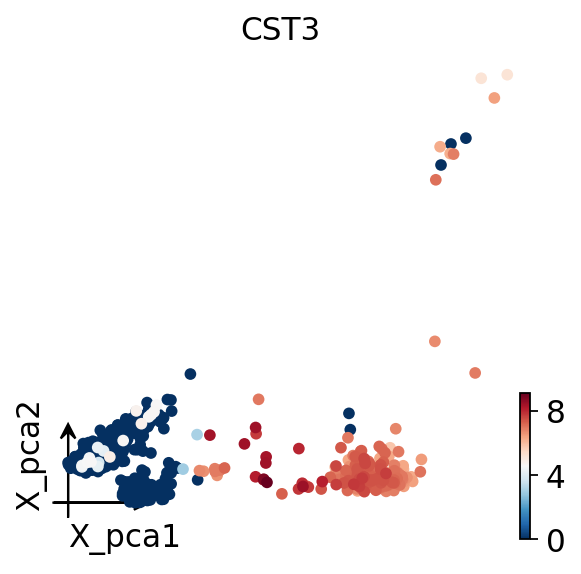

In [14]:
adata.obsm['X_pca'] = adata.obsm['scaled|original|X_pca']
ov.pl.embedding(adata,
                basis='X_pca',
                color='CST3',
                frameon='small')

## Summary

We took raw 10x pbmc_1k v3 reads all the way to an analysis-ready AnnData object
using the kb-python backend:

1. `ov.alignment.single.ref` built a kallisto index from the Ensembl GRCh38
   genome + GTF.
2. `ov.alignment.single.count` pseudoaligned the FASTQs with kallisto, corrected
   barcodes and counted UMIs with bustools, and emitted a filtered `.h5ad`.
3. The standard OmicVerse pipeline (QC -> preprocess -> HVG -> scale -> PCA ->
   embedding) recovered clear biological structure.

kb-python is attractive because it installs with a single `pip` command, is
extremely fast, and uses a small, near-constant amount of memory. For a
head-to-head comparison against the simpleaf / salmon / alevin-fry backend
(speed, cell calling, count concordance and clustering agreement) see the
[backend comparison tutorial](t_alignment_compare).